# Seaborn — Simple Guide for Students

**Seaborn** (`sns`) is a Python library for making beautiful charts.  
It works on top of **Matplotlib** and is great for data analysis.

### Quick cheat sheet — which plot to use?

| Plot | Function | Use when you want to... |
|------|----------|------------------------|
| Scatter | `sns.scatterplot()` | See relationship between **2 numbers** |
| Line | `sns.lineplot()` | Show **trend over time** |
| Bar | `sns.barplot()` | **Compare averages** across groups |
| Count | `sns.countplot()` | **Count** how many in each category |
| Histogram | `sns.histplot()` | See **distribution** of one number |
| KDE | `sns.kdeplot()` | Smooth **bell-curve** view of data |
| Box | `sns.boxplot()` | See **spread & outliers** by group |
| Violin | `sns.violinplot()` | See **full shape** of data by group |
| Heatmap | `sns.heatmap()` | Show **correlations** in a table |
| Pair | `sns.pairplot()` | Compare **many columns** at once |
| Regression | `sns.regplot()` | Scatter + **trend line** |

> **Tip:** Almost every seaborn plot uses `data=your_dataframe`, `x='column'`, and `y='column'`.

In [2]:
# Step 1: Install (run once)
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Step 2: Import libraries and load data
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../pandas/studentsample.csv')
df.head()

,student_id,name,age,gender,major,gpa,attendance_pct,city,enrollment_year,scholarship
0,S001,Alice Johnson,18.0,F,Computer Science,3.8,95.0,New York,2022.0,Yes
1,S002,Bob Smith,19.0,M,Mathematics,3.5,88.0,Boston,2021.0,No
2,S003,Charlie Brown,20.0,M,Physics,3.2,92.0,Chicago,2023.0,Yes
3,S004,Diana Prince,21.0,F,Biology,3.9,97.0,Seattle,2022.0,No
4,S005,Ethan Hunt,19.0,M,Chemistry,2.8,85.0,Austin,2021.0,NaN


---
## 1. Scatter Plot — `sns.scatterplot()`

**What it shows:** Dots for each student.  
**Use it when:** You want to see if two numbers are related (e.g. age vs GPA).

```python
sns.scatterplot(data=df, x='age', y='gpa')
```

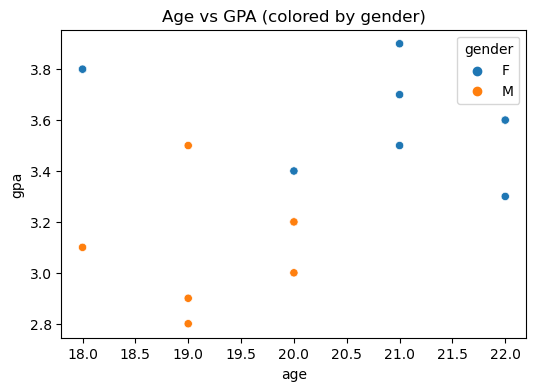

In [4]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age', y='gpa', hue='gender')
plt.title('Age vs GPA (colored by gender)')
plt.show()

---
## 2. Line Plot — `sns.lineplot()`

**What it shows:** A line connecting points.  
**Use it when:** You want to see a trend over time or ordered steps.

```python
sns.lineplot(data=df, x='enrollment_year', y='gpa')
```

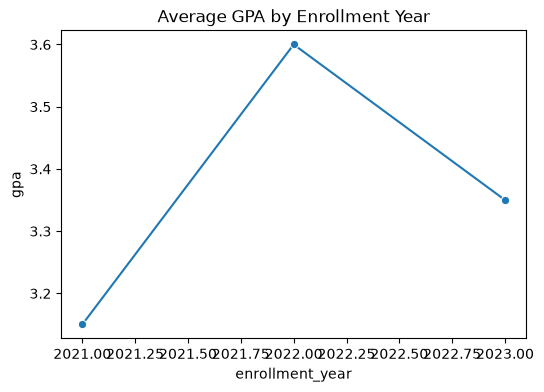

In [4]:
gpa_by_year = df.groupby('enrollment_year', as_index=False)['gpa'].mean()

plt.figure(figsize=(6, 4))
sns.lineplot(data=gpa_by_year, x='enrollment_year', y='gpa', marker='o')
plt.title('Average GPA by Enrollment Year')
plt.show()

---
## 3. Bar Plot — `sns.barplot()`

**What it shows:** Bars for each category (height = average or sum).  
**Use it when:** You want to compare groups like majors or cities.

```python
sns.barplot(data=df, x='major', y='gpa')
```

/Users/apple/anaconda3/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/Users/apple/anaconda3/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


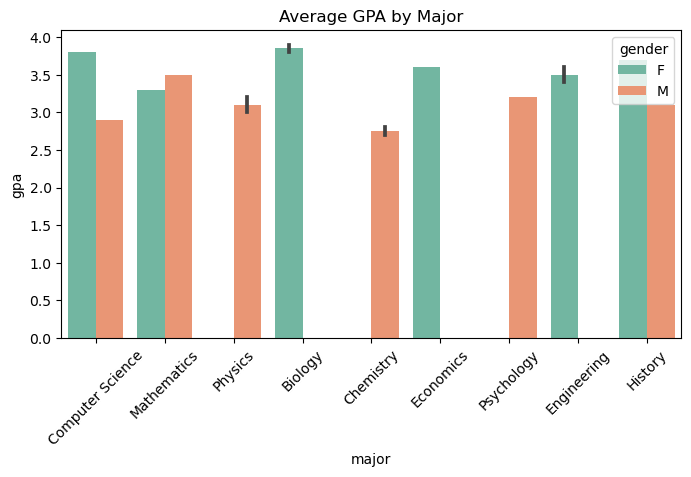

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='major', y='gpa', estimator='mean', hue='gender', palette='Set2')
plt.title('Average GPA by Major')
plt.xticks(rotation=45)
plt.show()

---
## 4. Count Plot — `sns.countplot()`

**What it shows:** How many items are in each category.  
**Use it when:** You just want to count (e.g. how many students per major).

```python
sns.countplot(data=df, x='major')
```

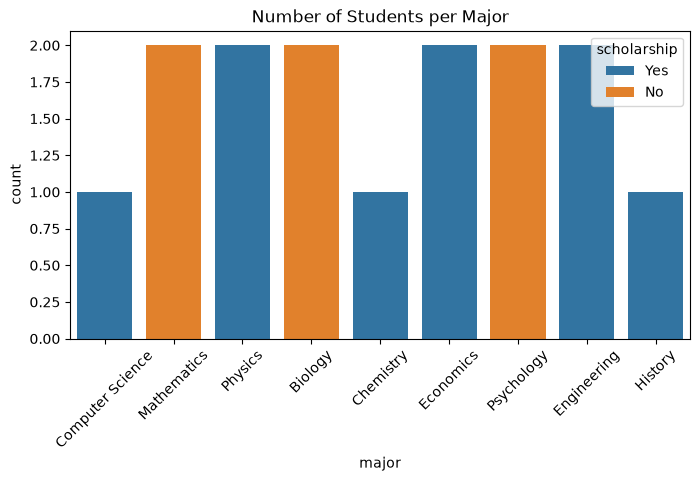

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='major', hue='scholarship')
plt.title('Number of Students per Major')
plt.xticks(rotation=45)
plt.show()

---
## 5. Histogram — `sns.histplot()`

**What it shows:** How often values fall in each range (bins).  
**Use it when:** You want the distribution of one number column.

```python
sns.histplot(df['gpa'], bins=5)
```

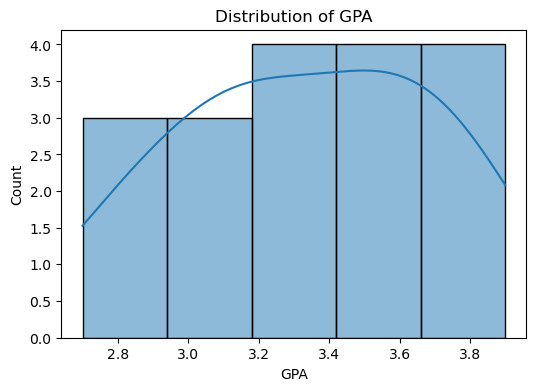

In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(df['gpa'], bins=5, kde=True)
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.show()

---
## 6. KDE Plot — `sns.kdeplot()`

**What it shows:** A smooth curve (like a bell shape).  
**Use it when:** You want a clean view of how data is spread.

```python
sns.kdeplot(df['attendance_pct'], fill=True)
```

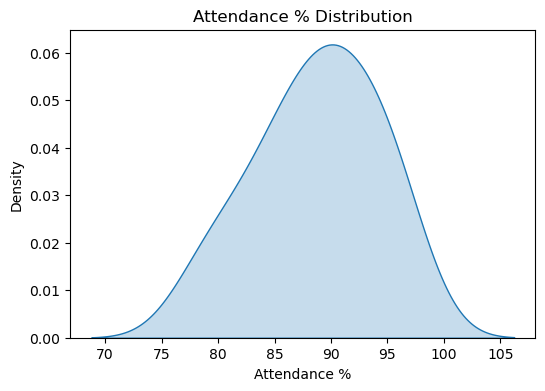

In [8]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['attendance_pct'], fill=True)
plt.title('Attendance % Distribution')
plt.xlabel('Attendance %')
plt.show()

---
## 7. Box Plot — `sns.boxplot()`

**What it shows:** Middle value, spread, and outliers (dots).  
**Use it when:** You want to compare spread between groups quickly.

```python
sns.boxplot(data=df, x='gender', y='gpa')
```

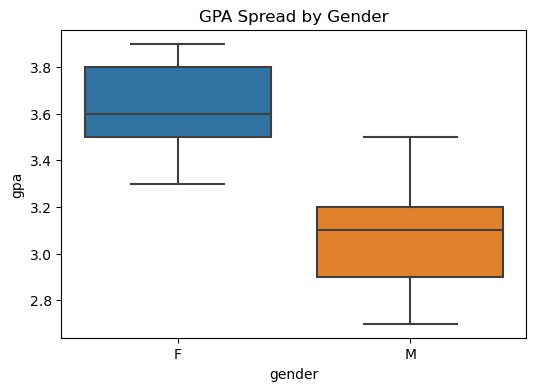

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='gender', y='gpa')
plt.title('GPA Spread by Gender')
plt.show()

---
## 8. Violin Plot — `sns.violinplot()`

**What it shows:** Shape of the data (thick = more values).  
**Use it when:** You want to see the full distribution per group.

```python
sns.violinplot(data=df, x='major', y='gpa')
```

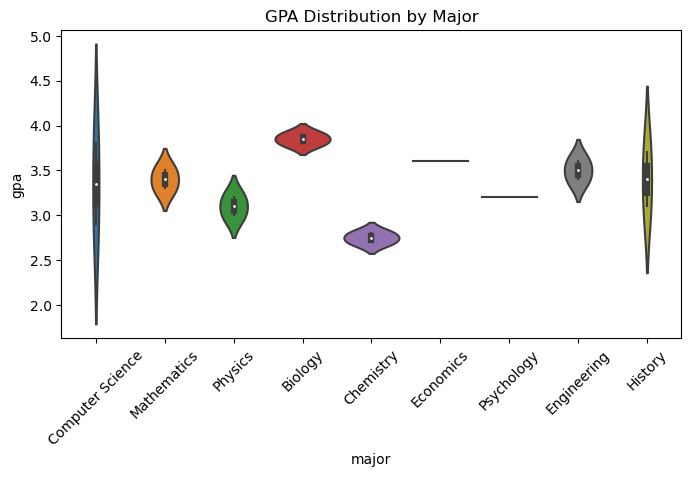

In [10]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='major', y='gpa')
plt.title('GPA Distribution by Major')
plt.xticks(rotation=45)
plt.show()

---
## 9. Heatmap — `sns.heatmap()`

**What it shows:** Colored grid — darker/lighter = higher/lower values.  
**Use it when:** You want to see which columns are related (correlation).

```python
sns.heatmap(df.corr(numeric_only=True), annot=True)
```

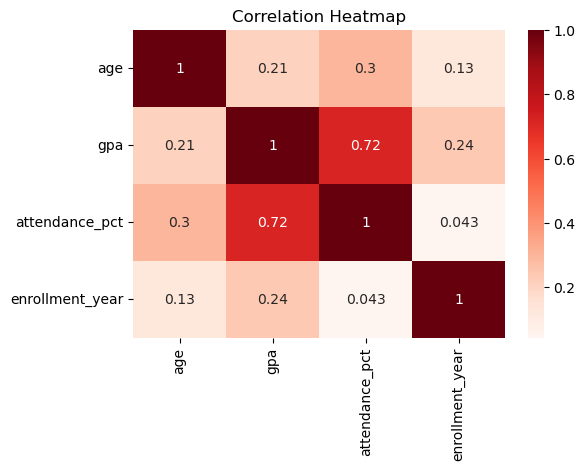

In [12]:
plt.figure(figsize=(6, 4))
corr = df[['age', 'gpa', 'attendance_pct', 'enrollment_year']].corr()
sns.heatmap(corr, annot=True, cmap='Reds')
plt.title('Correlation Heatmap')
plt.show()

---
## 10. Pair Plot — `sns.pairplot()`

**What it shows:** A grid of small charts for every pair of columns.  
**Use it when:** You want a quick overview of many relationships.

```python
sns.pairplot(df, vars=['age', 'gpa', 'attendance_pct'])
```

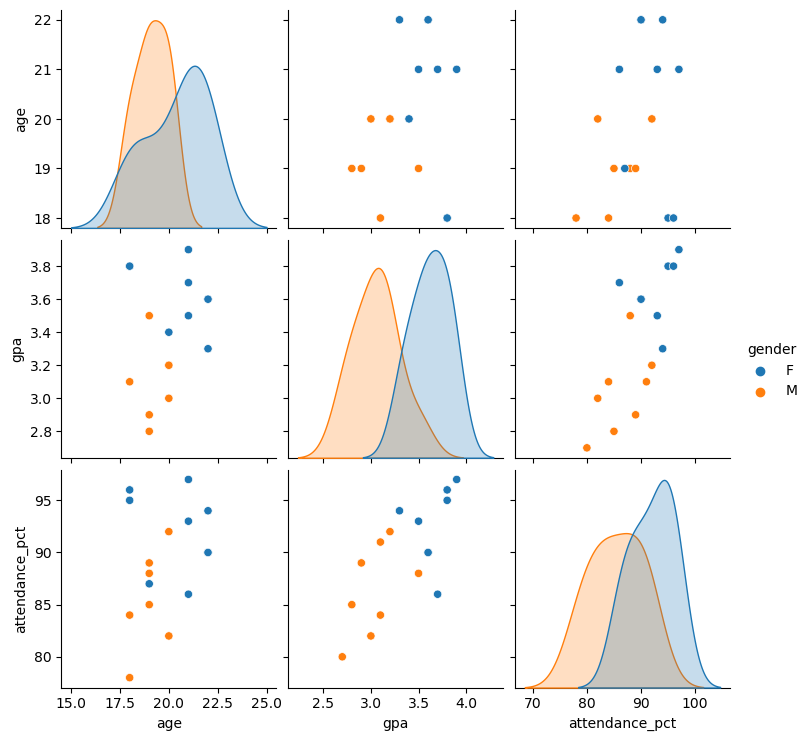

In [13]:
sns.pairplot(df, vars=['age', 'gpa', 'attendance_pct'], hue='gender')
plt.show()

---
## 11. Regression Plot — `sns.regplot()`

**What it shows:** Scatter plot + best-fit straight line.  
**Use it when:** You want to see if one variable increases/decreases with another.

```python
sns.regplot(data=df, x='attendance_pct', y='gpa')
```

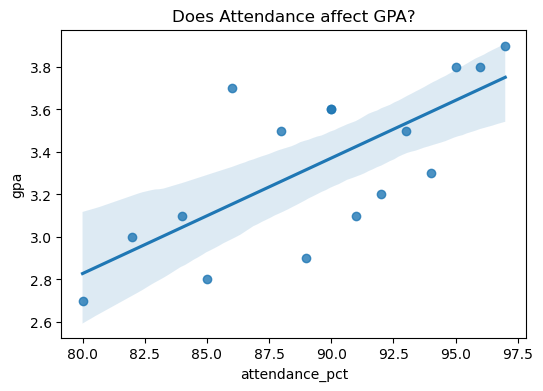

In [16]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='attendance_pct', y='gpa')
plt.title('Does Attendance affect GPA?')
plt.show()

---
## Bonus: Strip & Swarm Plots

These show **every single data point** on a category axis.

| Plot | Function | Look |
|------|----------|------|
| Strip | `sns.stripplot()` | Dots in a line (can overlap) |
| Swarm | `sns.swarmplot()` | Dots spread so they don't overlap |

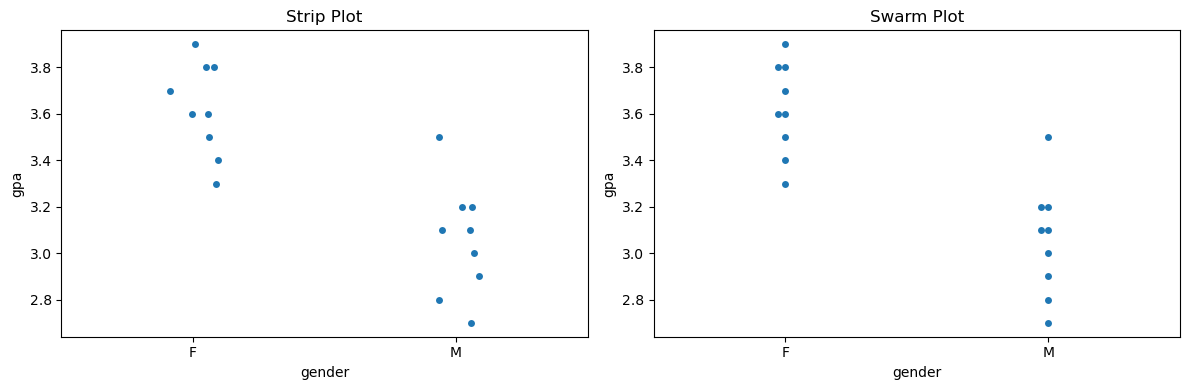

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.stripplot(data=df, x='gender', y='gpa', ax=axes[0])
axes[0].set_title('Strip Plot')

sns.swarmplot(data=df, x='gender', y='gpa', ax=axes[1])
axes[1].set_title('Swarm Plot')

plt.tight_layout()
plt.show()

---
## Summary — Remember These 3 Things

1. **Import:** `import seaborn as sns`
2. **Basic pattern:** `sns.plotname(data=df, x='col1', y='col2')`
3. **Show chart:** `plt.show()`

### Common extra options
- `hue='column'` → color points/bars by a category
- `plt.title('My Title')` → add a title
- `plt.xticks(rotation=45)` → rotate long labels
- `plt.figure(figsize=(8, 4))` → make chart bigger

**Practice idea:** Pick any column from the student data and try 2–3 different plot types on it!